In [9]:
import pandas as pd

# ---- Load CSV ----
input_path = "combined_results.csv"          # change this
output_path = "only_fix_nonmask.csv"

df = pd.read_csv(input_path)

# ---- Keep only fix_nonmask rows ----
df_filtered = df[df["tag"] == "fix_nonmask"].copy()

# ---- Save (optional) ----
df_filtered.to_csv(output_path, index=False)

print("Original rows:", len(df))
print("Filtered rows:", len(df_filtered))
print("Saved to:", output_path)

Original rows: 600
Filtered rows: 200
Saved to: only_fix_nonmask.csv


In [10]:
import pandas as pd
import re
import os

ABCROWN_CSV = "results_abcrown.csv"
NONMASK_CSV = "only_fix_nonmask.csv"
OUT_CSV     = "results_abcrown_with_semantic.csv"

# -----------------------
# Load
# -----------------------
abc = pd.read_csv(ABCROWN_CSV, header=None)
abc.columns = ["benchmark", "onnx_path", "vnnlib_path",
               "runtime", "status", "all_time"]

non = pd.read_csv(NONMASK_CSV)

# -----------------------
# Helpers
# -----------------------
def extract_idx_from_image(image_str):
    m = re.search(r"__idx_(\d+)", str(image_str))
    return int(m.group(1)) if m else None

def extract_eps_from_vnnlib(vnnlib_path):
    m = re.search(r"_eps_([0-9]*\.?[0-9]+)", str(vnnlib_path))
    return float(m.group(1)) if m else None

def extract_sidx_from_vnnlib(vnnlib_path):
    m = re.search(r"_sidx_(\d+)", str(vnnlib_path))
    return int(m.group(1)) if m else None

def extract_model_from_onnx(onnx_path):
    base = os.path.basename(str(onnx_path))
    if base.lower().endswith(".onnx"):
        base = base[:-5]
    return base

# -----------------------
# Build semantic mapping
# -----------------------
non = non.copy()

non["model_key"] = non["model"].astype(str)
non["idx"] = non["image"].map(extract_idx_from_image)
non["eps_f"] = pd.to_numeric(non["eps"], errors="coerce")

# IMPORTANT:
# Here I assume semantic result is stored in column "result"
# If your semantic result column has another name, change it here.
if "result" not in non.columns:
    raise ValueError("Semantic CSV must contain a 'result' column.")

sem_map = (
    non.dropna(subset=["model_key", "idx", "eps_f"])
       .set_index(["model_key", "idx", "eps_f"])[["all_time", "result"]]
       .to_dict("index")
)

# -----------------------
# Apply to AB-CROWN
# -----------------------
abc = abc.copy()
abc["model_key"] = abc["onnx_path"].map(extract_model_from_onnx)
abc["idx"] = abc["vnnlib_path"].map(extract_sidx_from_vnnlib)
abc["eps_f"] = abc["vnnlib_path"].map(extract_eps_from_vnnlib)

def semantic_override(row):
    key = (row["model_key"], row["idx"], row["eps_f"])
    if key in sem_map:
        return pd.Series({
            "status": sem_map[key]["result"],
            "all_time": sem_map[key]["all_time"]
        })
    else:
        return pd.Series({
            "status": row["status"],
            "all_time": row["all_time"]
        })

abc[["status", "all_time"]] = abc.apply(semantic_override, axis=1)

# -----------------------
# Save
# -----------------------
abc[["benchmark", "onnx_path", "vnnlib_path",
     "runtime", "status", "all_time"]].to_csv(
    OUT_CSV, index=False, header=False
)

print("Saved:", OUT_CSV)

Saved: results_abcrown_with_semantic.csv


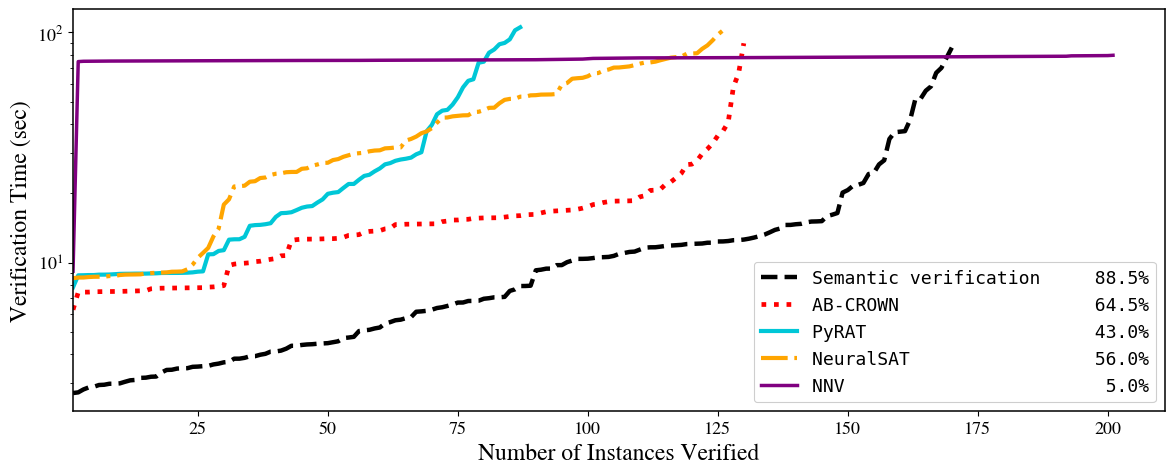

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import LogLocator, LogFormatterMathtext

# ---------------------------
# Paper style
# ---------------------------
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 15,
    "axes.labelsize": 17,
    "legend.fontsize": 13,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "axes.linewidth": 1.1,
    "pdf.fonttype": 42,
})

# ---------------------------
# Solved percentages (for legend)
# ---------------------------
SOLVED_PCT = {
    "Semantic verification": "88.5%",
    "AB-CROWN":              "64.5%",
    "PyRAT":                 "43.0%",
    "NeuralSAT":             "56.0%",
    "NNV":                   "5.0%",
}

# ---------------------------
# Files
# ---------------------------
FILES = [
    ("results_XAIV.csv",       "Semantic verification", dict(color="black", linestyle="--", linewidth=3.2)),
    ("results_abcrown.csv",    "AB-CROWN",              dict(color="red", linestyle=":", linewidth=3.4)),
    ("results_pyrat.csv",      "PyRAT",                 dict(color="#00C7D7", linestyle="-", linewidth=3.0)),
    ("results_neuralsat.csv",  "NeuralSAT",             dict(color="orange", linestyle="-.", linewidth=3.0)),
    ("results_nnv.csv",        "NNV",                   dict(color="purple", linestyle="-", linewidth=2.5)),
]

# ---------------------------
# Loader
# ---------------------------
def load_cactus(path, runtime_column=5):
    df = pd.read_csv(path, header=None)
    df.columns = [f"c{i}" for i in range(df.shape[1])]

    time = pd.to_numeric(df[f"c{runtime_column}"], errors="coerce")
    status = df["c4"].astype(str).str.lower()

    # treat anything not containing timeout as solved
    solved = ~status.str.contains("timeout")

    times = np.sort(time[solved & time.notna()].values)
    x = np.arange(1, len(times) + 1)

    return x, times
# ---------------------------
# Plot
# ---------------------------
fig, ax = plt.subplots(figsize=(12, 5))

handles = []
labels = []

for path, name, style in FILES:
    x, y = load_cactus(path, runtime_column=5)

    if len(y) > 0:
        (line,) = ax.plot(x, y, **style)
        handles.append(line)

        pct = SOLVED_PCT.get(name, "")
        labels.append(f"{name:<22} {pct:>8}")

# log scale
ax.set_yscale("log")
ax.yaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_major_formatter(LogFormatterMathtext())

ax.set_xlabel("Number of Instances Verified")
ax.set_ylabel("Verification Time (sec)")
ax.set_xlim(left=1)
ax.grid(False)

# ---- Aligned legend
leg = ax.legend(
    handles,
    labels,
    loc="lower right",
    frameon=True,
    fancybox=True,
    framealpha=0.95,
    prop={"family": "DejaVu Sans Mono", "size": 13},  # <-- monospace
)

leg.get_frame().set_linewidth(0.8)

plt.tight_layout()
plt.savefig("cactus_plot.pdf", bbox_inches="tight")
plt.show()